# Diabetes 130-US — Exploratory Data Analysis (T-202)

**MedScope AI** · Fase 2 ML · UC-110 · RIA-001

Notebook de exploracion del dataset [Diabetes 130-US hospitals](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) (Strack et al., 2014).

**Objetivos:**
- Entender estructura, missing values y calidad de datos
- Analizar desbalance de la variable objetivo 
eadmitted
- Explorar distribuciones y correlaciones
- Documentar hallazgos para preprocessing (T-203) y feature engineering (T-204)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PATH = REPO_ROOT / 'datasets' / 'diabetes130' / 'raw' / 'data.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}. Run: python ml/scripts/download_dataset.py'
    )

DATA_PATH


WindowsPath('c:/Pojects/medscope-ai/datasets/diabetes130/raw/data.csv')

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Rows: {len(df):,}  |  Columns: {len(df.columns)}')
df.head()


Rows: 101,766  |  Columns: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 1. Tipos de datos y resumen estadistico


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [5]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


## 2. Valores faltantes y placeholders

En este dataset, los missing suelen codificarse como ? o None (texto), no como NaN de pandas.


In [6]:
PLACEHOLDER_VALUES = {'?', 'Unknown', 'NULL', 'none', 'None'}

def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in frame.columns:
        series = frame[col].astype(str)
        placeholder_count = series.isin(PLACEHOLDER_VALUES).sum()
        nan_count = frame[col].isna().sum()
        rows.append({
            'column': col,
            'nan': int(nan_count),
            'placeholder': int(placeholder_count),
            'missing_total': int(nan_count + placeholder_count),
            'missing_pct': round(100 * (nan_count + placeholder_count) / len(frame), 2),
        })
    return pd.DataFrame(rows).sort_values('missing_pct', ascending=False)

missing = missing_summary(df)
missing.head(15)


,column,nan,placeholder,missing_total,missing_pct
5,weight,98569,0,98569,96.86
22,max_glu_serum,96420,0,96420,94.75
23,A1Cresult,84748,0,84748,83.28
11,medical_specialty,49949,0,49949,49.08
10,payer_code,40256,0,40256,39.56
2,race,2273,0,2273,2.23
20,diag_3,1423,0,1423,1.40
19,diag_2,358,0,358,0.35
18,diag_1,21,0,21,0.02
1,patient_nbr,0,0,0,0.00


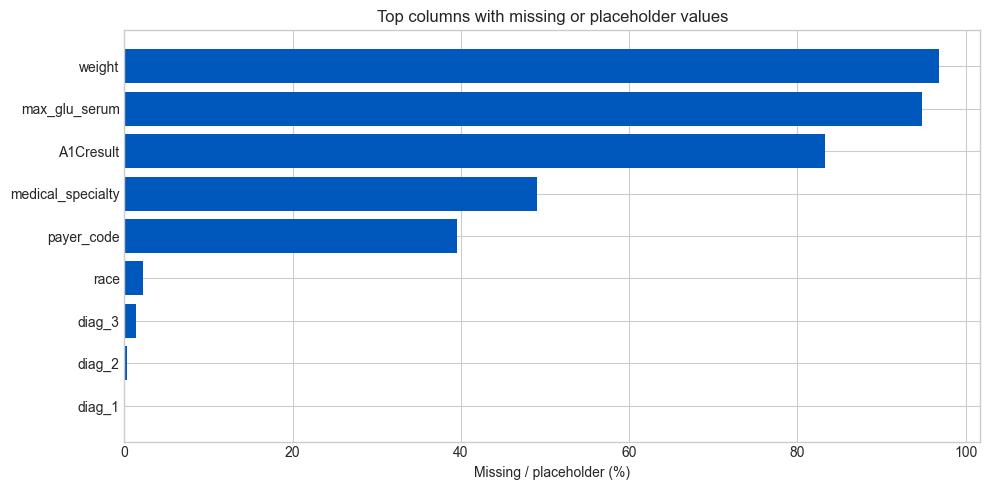

In [7]:
top_missing = missing[missing['missing_pct'] > 0].head(12)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_missing['column'], top_missing['missing_pct'], color='#0058bc')
ax.set_xlabel('Missing / placeholder (%)')
ax.set_title('Top columns with missing or placeholder values')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Variable objetivo — 
readmitted

Distribucion de readmision hospitalaria. Para el MVP se recomienda un target binario: **readmitido <30 dias** vs resto.


In [19]:
target_counts = df['readmitted'].value_counts()
target_pct = df['readmitted'].value_counts(normalize=True).mul(100).round(2)

summary = pd.DataFrame({'count': target_counts, 'pct': target_pct})
summary


,count,pct
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


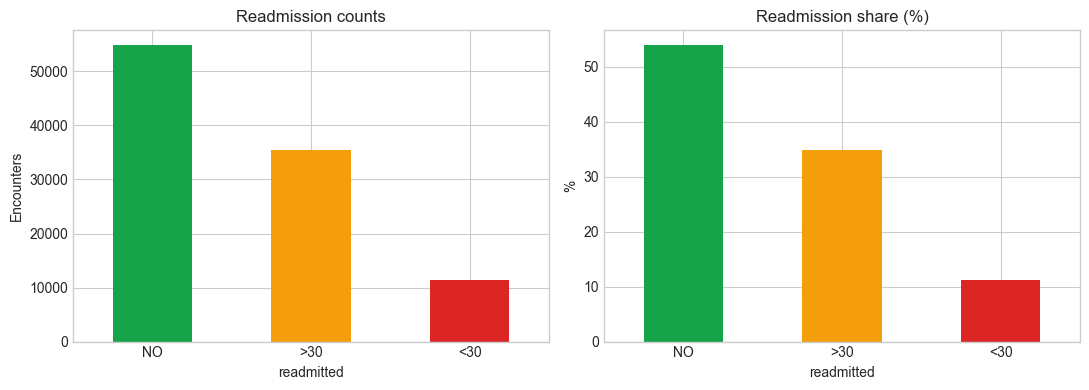

In [20]:
colors = {'NO': '#16a34a', '>30': '#f59e0b', '<30': '#dc2626'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

summary['count'].plot(kind='bar', ax=axes[0], color=[colors.get(x, '#0058bc') for x in summary.index])
axes[0].set_title('Readmission counts')
axes[0].set_xlabel('readmitted')
axes[0].set_ylabel('Encounters')
axes[0].tick_params(axis='x', rotation=0)

summary['pct'].plot(kind='bar', ax=axes[1], color=[colors.get(x, '#0058bc') for x in summary.index])
axes[1].set_title('Readmission share (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [21]:
df['readmit_30d'] = (df['readmitted'] == '<30').astype(int)
print('Binary target readmit_30d:')
print(df['readmit_30d'].value_counts())
print('Positive rate:', round(df['readmit_30d'].mean() * 100, 2), '%')


Binary target readmit_30d:
readmit_30d
0    90409
1    11357
Name: count, dtype: int64
Positive rate: 11.16 %


## 4. Distribuciones — variables numericas clave (MVP)

Alineadas con patient_inputs en Database.md y datasets/manifest.json.


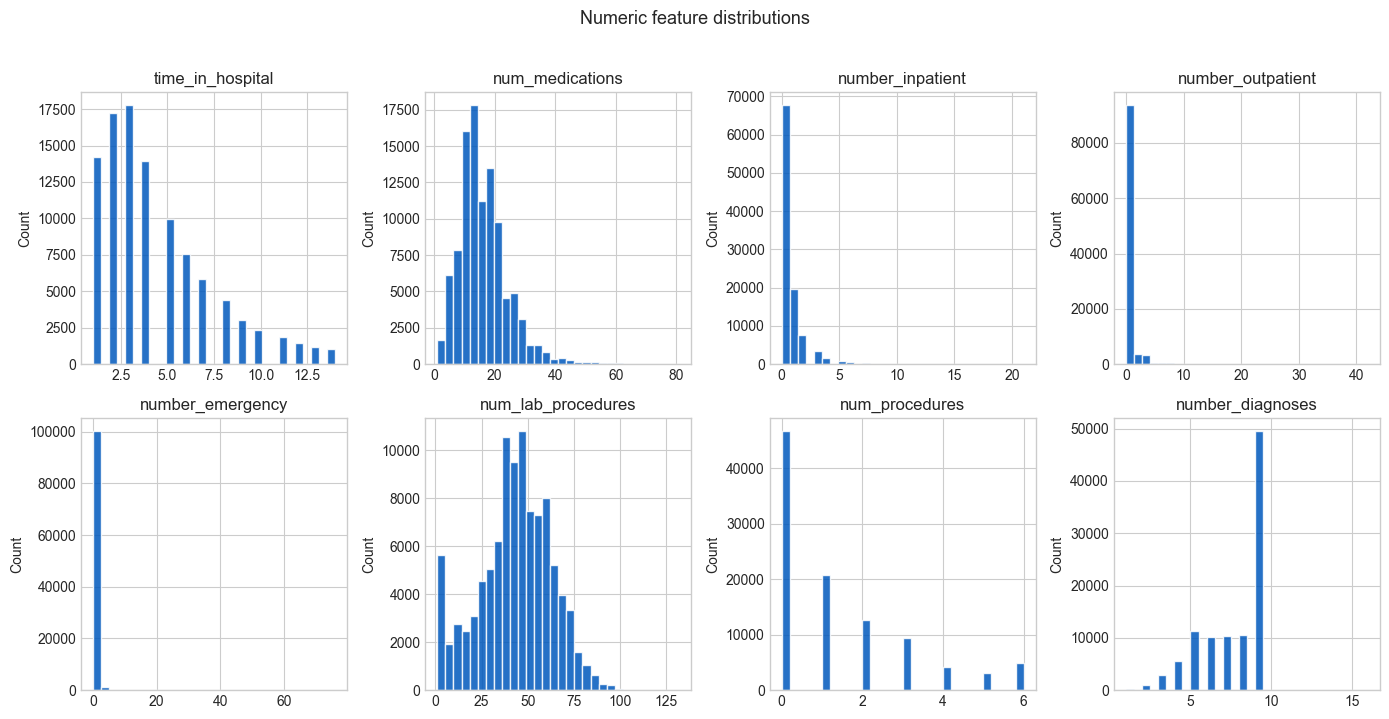

In [23]:
mvp_numeric = [
    'time_in_hospital',
    'num_medications',
    'number_inpatient',
    'number_outpatient',
    'number_emergency',
    'num_lab_procedures',
    'num_procedures',
    'number_diagnoses',
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for ax, col in zip(axes, mvp_numeric):
    ax.hist(df[col].dropna(), bins=30, color='#0058bc', alpha=0.85, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.suptitle('Numeric feature distributions', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 5. Variables categoricas MVP


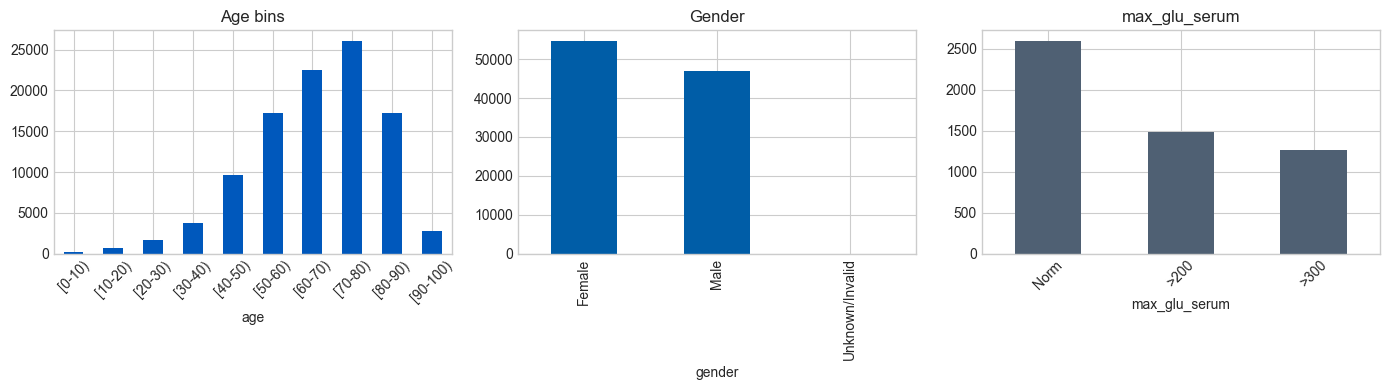

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['age'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#0058bc')
axes[0].set_title('Age bins')
axes[0].tick_params(axis='x', rotation=45)

df['gender'].value_counts().plot(kind='bar', ax=axes[1], color='#005da7')
axes[1].set_title('Gender')

df['max_glu_serum'].value_counts().plot(kind='bar', ax=axes[2], color='#4f6073')
axes[2].set_title('max_glu_serum')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 6. Correlaciones (variables numericas)

Matriz de correlacion de Pearson sobre columnas numericas. Util para detectar redundancia antes del modelado.


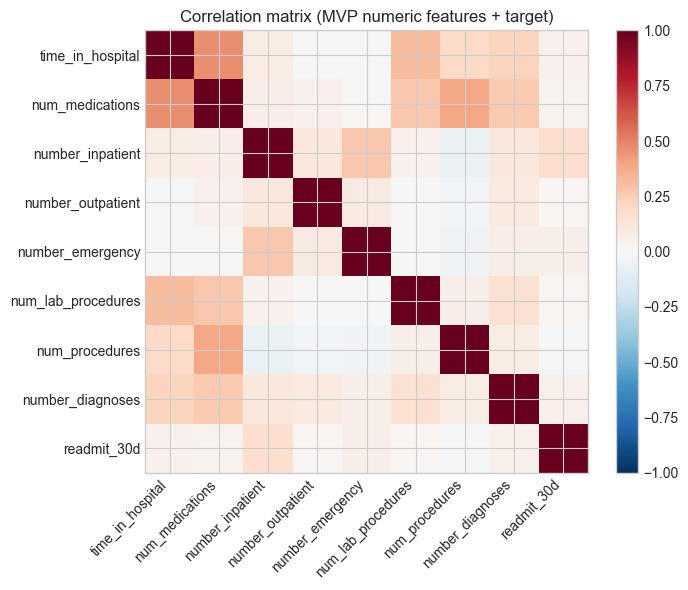

number_inpatient      0.165147
number_emergency      0.060747
number_diagnoses      0.049524
time_in_hospital      0.044199
num_medications       0.038432
num_lab_procedures    0.020364
number_outpatient     0.018893
num_procedures       -0.012227
Name: readmit_30d, dtype: float64

In [25]:
corr = df[mvp_numeric + ['readmit_30d']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation matrix (MVP numeric features + target)')
plt.tight_layout()
plt.show()

corr['readmit_30d'].drop('readmit_30d').sort_values(key=abs, ascending=False)


## 7. Tasa de readmision <30d por grupos


In [26]:
def readmit_rate_by(column: str) -> pd.DataFrame:
  grouped = df.groupby(column)['readmit_30d'].agg(['mean', 'count'])
  grouped['readmit_rate_pct'] = (grouped['mean'] * 100).round(2)
  return grouped.sort_values('readmit_rate_pct', ascending=False)

for col in ['age', 'gender', 'time_in_hospital', 'num_medications']:
    print(f'\n=== {col} ===')
    display(readmit_rate_by(col).head(8))



=== age ===


,mean,count,readmit_rate_pct
age,,,
[20-30),0.142426,1657,14.24
[80-90),0.120835,17197,12.08
[70-80),0.117731,26068,11.77
[30-40),0.112318,3775,11.23
[60-70),0.111284,22483,11.13
[90-100),0.110992,2793,11.10
[40-50),0.106040,9685,10.60
[50-60),0.096662,17256,9.67



=== gender ===


,mean,count,readmit_rate_pct
gender,,,
Female,0.112452,54708,11.25
Male,0.110615,47055,11.06
Unknown/Invalid,0.000000,3,0.00



=== time_in_hospital ===


,mean,count,readmit_rate_pct
time_in_hospital,,,
10,0.143467,2342,14.35
8,0.142337,4391,14.23
9,0.137242,3002,13.72
12,0.133287,1448,13.33
14,0.129559,1042,12.96
7,0.128350,5859,12.83
6,0.125879,7539,12.59
13,0.123140,1210,12.31



=== num_medications ===


,mean,count,readmit_rate_pct
num_medications,,,
81,1.000000,1,100.00
72,1.000000,3,100.00
70,0.500000,2,50.00
67,0.285714,7,28.57
68,0.285714,7,28.57
55,0.187500,32,18.75
35,0.164948,388,16.49
47,0.162162,74,16.22


## 8. Encounters duplicados por paciente

Strack et al. (2014) recomiendan filtrar encuentros duplicados por paciente antes de entrenar. Exploramos el volumen para T-203.


In [27]:
encounters_per_patient = df.groupby('patient_nbr')['encounter_id'].count()
print('Patients:', df['patient_nbr'].nunique())
print('Encounters:', len(df))
print('Encounters per patient — describe:')
encounters_per_patient.describe()


Patients: 71518
Encounters: 101766
Encounters per patient — describe:


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: encounter_id, dtype: float64

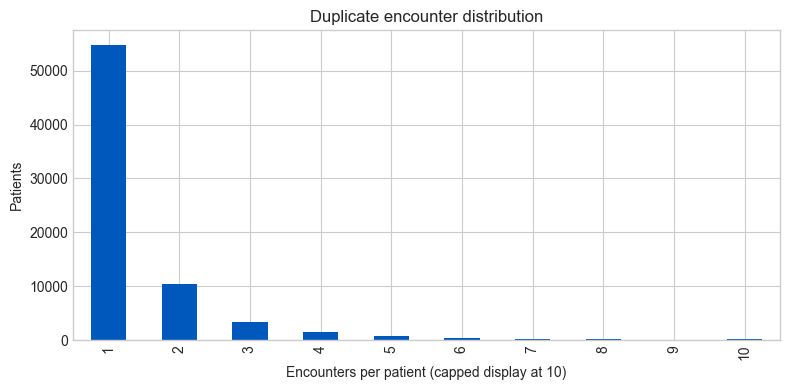

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
encounters_per_patient.clip(upper=10).value_counts().sort_index().plot(kind='bar', ax=ax, color='#0058bc')
ax.set_xlabel('Encounters per patient (capped display at 10)')
ax.set_ylabel('Patients')
ax.set_title('Duplicate encounter distribution')
plt.tight_layout()
plt.show()


## 9. Conclusiones para siguientes tareas

| Hallazgo | Implicacion |
|---|---|
| **Desbalance fuerte** (~11% positivos <30) | Priorizar **Recall** en metricas (RIA-012); usar class_weight o stratified split |
| **weight casi vacio** | No usar BMI en baseline; coherente con patient_inputs.bmi opcional |
| **Placeholders ? / None** | Normalizar en preprocessing (T-203) antes de encoding |
| **ge en bins ordinales** | Parsear orden en T-203/T-204 |
| **Encounters duplicados** | Aplicar filtro por patient_nbr en T-203 (criterio documentado) |
| **Target binario <30 vs resto** | Alineado con readmission risk MVP y UC-022 |

**Siguiente:** T-203 preprocessing reproducible · T-204 feature engineering · T-205 baseline Logistic Regression
